# Aral Sea -- Water Extent Time Series (2005-2024)

The Aral Sea in Central Asia is one of the most dramatic examples of
human-induced environmental change. Fed by the Amu Darya and Syr Darya
rivers, it began shrinking in the 1960s after Soviet irrigation projects
diverted its inflows. By the 2010s the South Aral had almost completely
disappeared.

This notebook builds a multi-decadal time series using:
- **Landsat Collection 2 Level-2** (2005-2015)
- **Sentinel-2 Level-2A** (2016 onwards)

Both datasets are accessed live from **Microsoft Planetary Computer** via STAC.
Data is read directly from Cloud-Optimised GeoTIFFs using `rasterio` --
no extra geospatial stack required.

**Workflow:** search -> load bands -> spectral indices -> binary water mask -> GIF


## 1. Imports and configuration


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from io import BytesIO
import os

import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_bounds as make_transform
from rasterio.crs import CRS

import pystac_client
import planetary_computer
import imageio.v3 as iio

# ---------------------------------------------------------------------------
# Aral Sea region of interest (WGS84: lon_min, lat_min, lon_max, lat_max)
BBOX = [57.5, 43.5, 62.5, 46.8]

# Summer window -- minimal cloud cover over Central Asia
SEASON_START = "07-01"
SEASON_END   = "09-30"

CLOUD_MAX  = 15   # maximum cloud cover (%)
RESOLUTION = 300  # output pixel size in metres

# Target CRS: UTM zone 41N covers the Aral Sea
TARGET_CRS = CRS.from_epsg(32641)
WGS84      = CRS.from_epsg(4326)

# Pre-compute the common output grid (all scenes will be reprojected onto this)
UTM_BOUNDS    = transform_bounds(WGS84, TARGET_CRS, *BBOX)
GRID_WIDTH    = int((UTM_BOUNDS[2] - UTM_BOUNDS[0]) / RESOLUTION)
GRID_HEIGHT   = int((UTM_BOUNDS[3] - UTM_BOUNDS[1]) / RESOLUTION)
GRID_TRANSFORM = make_transform(*UTM_BOUNDS, GRID_WIDTH, GRID_HEIGHT)

print(f"Output grid : {GRID_WIDTH} x {GRID_HEIGHT} px  ({RESOLUTION} m/px)")
print(f"UTM bounds  : {[round(v) for v in UTM_BOUNDS]} m")


Output grid : 1355 x 1270 px  (300 m/px)
UTM bounds  : [55320, 4816463, 461846, 5197644] m


## 2. Connect to Planetary Computer

Planetary Computer is a free public STAC catalogue by Microsoft hosting
the full Landsat and Sentinel-2 archives. Asset URLs must be *signed* before
download; `planetary_computer.sign_inplace` handles this automatically.


In [2]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
print("Connected:", catalog.title)


Connected: Microsoft Planetary Computer STAC API


## 3. Band loading helpers

We read data directly from Cloud-Optimised GeoTIFFs (COGs) using `rasterio`.
Each band is reprojected on-the-fly onto the common UTM grid so all scenes
share the same pixel alignment regardless of sensor or path/row.

`get_asset_href()` resolves a band by its *common name* (e.g. `green`, `nir08`)
so the same code works for both Landsat and Sentinel-2 STAC items.


In [3]:
BAND_ALIASES = {
    'green':  ['green',  'B03'],
    'nir08':  ['nir08',  'nir',  'B08', 'B8A'],
    'swir16': ['swir16', 'swir', 'B11'],
}


def get_asset_href(item, common_name):
    """Resolve a band by common name with sensor-agnostic aliases."""
    aliases = BAND_ALIASES.get(common_name, [common_name])
    for asset in item.assets.values():
        for band in asset.extra_fields.get('eo:bands', []):
            if band.get('common_name') in aliases:
                return asset.href
    for alias in aliases:
        if alias in item.assets:
            return item.assets[alias].href
    raise KeyError(f"Band '{common_name}' not found in {item.id}. "
                   f"Available: {list(item.assets.keys())}")


def load_band(href):
    """
    Read one band from a COG, clipped and reprojected to the common UTM grid.
    rasterio only fetches the COG tiles that overlap the destination window,
    so this is already an efficient windowed read.
    Returns float32 array (GRID_HEIGHT x GRID_WIDTH); 0 = outside footprint.
    """
    out = np.zeros((GRID_HEIGHT, GRID_WIDTH), dtype=np.float32)
    with rasterio.open(href) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=GRID_TRANSFORM,
            dst_crs=TARGET_CRS,
            resampling=Resampling.average,
            src_nodata=src.nodata,
            dst_nodata=0.0,
        )
    return out


def load_median_mosaic(items, scale, offset=0.0, max_scenes=8):
    """
    Build an annual median composite from the N least-cloudy scenes.

    Each scene is clipped to the AOI and reprojected onto the common UTM
    grid.  All scenes are stacked along a new axis and nanmedian is taken
    per pixel, which naturally suppresses clouds, shadows and Landsat 7
    scan-line gaps that affect individual acquisitions.

    items      : STAC items pre-sorted by cloud cover ascending
    scale/offset: reflectance = DN * scale + offset
    max_scenes : cap on how many scenes to load (default 8)
    """
    selected = items[:max_scenes]
    result   = {}

    for band in ('green', 'nir08', 'swir16'):
        stack = []
        for item in selected:
            try:
                href = get_asset_href(item, band)
                arr  = load_band(href).astype(np.float32) * scale + offset
                arr[arr <= 0] = np.nan   # outside footprint or fill -> NaN
                arr[arr >  1] = np.nan   # physically invalid
                stack.append(arr)
            except Exception:
                continue

        if stack:
            median = np.nanmedian(np.stack(stack, axis=0), axis=0)
            result[band] = np.nan_to_num(median, nan=0.0).astype(np.float32)
        else:
            result[band] = np.zeros((GRID_HEIGHT, GRID_WIDTH), dtype=np.float32)

    return result


print('Helpers defined.')


Helpers defined.


## 4. Landsat search -- 2005 to 2015

**Collection:** `landsat-c2-l2` (Collection 2, Level-2 Surface Reflectance).  
Covers Landsat 5 TM, 7 ETM+ and 8 OLI.  
One least-cloudy summer scene per year is selected.

Landsat C2 L2 scale factors: **DN x 0.0000275 - 0.2**


In [4]:
landsat_items = {}   # year -> list of items (sorted by cloud cover)

for year in range(2005, 2016):
    for cloud_limit in (CLOUD_MAX, 40, 80):
        search = catalog.search(
            collections=['landsat-c2-l2'],
            bbox=BBOX,
            datetime=f'{year}-{SEASON_START}/{year}-{SEASON_END}',
            query={'eo:cloud_cover': {'lt': cloud_limit}},
        )
        items = list(search.items())
        if items:
            break

    items.sort(key=lambda x: x.properties.get('eo:cloud_cover', 100))
    landsat_items[year] = items
    platforms = set(i.properties.get('platform', '?') for i in items)
    clouds    = [round(i.properties.get('eo:cloud_cover', 0), 1) for i in items[:3]]
    print(f'{year}: {len(items):2d} scenes  platforms={platforms}  best clouds={clouds}')


2005: LE07_L2SP_161030_20050929_02_T1  [landsat-7]  cloud=0.0%
2006: LT05_L2SP_159030_20060926_02_T1  [landsat-5]  cloud=0.0%
2007: LE07_L2SP_158030_20070930_02_T1  [landsat-7]  cloud=0.0%
2008: LE07_L2SP_159029_20080923_02_T1  [landsat-7]  cloud=0.0%
2009: LT05_L2SP_158030_20090927_02_T1  [landsat-5]  cloud=0.0%
2010: LT05_L2SP_158030_20100930_02_T1  [landsat-5]  cloud=0.0%
2011: LE07_L2SP_158030_20110925_02_T1  [landsat-7]  cloud=0.0%
2012: LE07_L2SP_158030_20120927_02_T1  [landsat-7]  cloud=0.0%
2013: LE07_L2SP_158030_20130930_02_T1  [landsat-7]  cloud=0.0%
2014: LE07_L2SP_160030_20140915_02_T1  [landsat-7]  cloud=0.0%
2015: LE07_L2SP_159030_20150927_02_T1  [landsat-7]  cloud=0.0%

Total: 11 Landsat scenes


### Load Landsat scenes


In [5]:
LS_SCALE  =  0.0000275
LS_OFFSET = -0.2

landsat_data = {}
for year, items in sorted(landsat_items.items()):
    n = min(len(items), 8)
    print(f'{year}: median of {n} scenes ...', end=' ', flush=True)
    landsat_data[year] = load_median_mosaic(items, scale=LS_SCALE, offset=LS_OFFSET)
    coverage = np.mean(landsat_data[year]['green'] > 0) * 100
    print(f'coverage={coverage:.0f}%')

print('Done.')


Loading 2005 ... OK
Loading 2006 ... OK
Loading 2007 ... OK
Loading 2008 ... OK
Loading 2009 ... OK
Loading 2010 ... OK
Loading 2011 ... OK
Loading 2012 ... OK
Loading 2013 ... OK
Loading 2014 ... OK
Loading 2015 ... OK
Done.


## 5. Sentinel-2 search -- 2016 to present

**Collection:** `sentinel-2-l2a`.  
Bands: `green` (B03, 10 m), `nir08` (B08, 10 m), `swir16` (B11, 20 m).  
Sentinel-2 L2A scale factor: **DN x 0.0001** (divide by 10 000).


In [6]:
s2_items = {}   # year -> list of items (sorted by cloud cover)

for year in range(2016, 2025):
    for cloud_limit in (CLOUD_MAX, 40, 80):
        search = catalog.search(
            collections=['sentinel-2-l2a'],
            bbox=BBOX,
            datetime=f'{year}-{SEASON_START}/{year}-{SEASON_END}',
            query={'eo:cloud_cover': {'lt': cloud_limit}},
        )
        items = list(search.items())
        if items:
            break

    items.sort(key=lambda x: x.properties.get('eo:cloud_cover', 100))
    s2_items[year] = items
    clouds = [round(i.properties.get('eo:cloud_cover', 0), 1) for i in items[:3]]
    print(f'{year}: {len(items):2d} scenes  best clouds={clouds}')


2016: S2A_MSIL2A_20160803T071312_R106_T40TEQ_202  cloud=0.1%
2017: S2B_MSIL2A_20170916T064619_R020_T40TGT_202  cloud=0.0%
2018: S2B_MSIL2A_20180719T070619_R106_T40TFP_202  cloud=0.0%
2019: S2B_MSIL2A_20190817T064629_R020_T40TGT_202  cloud=0.0%
2020: S2B_MSIL2A_20200827T070629_R106_T40TES_202  cloud=0.1%
2021: S2B_MSIL2A_20210925T064619_R020_T40TGT_202  cloud=0.0%
2022: S2A_MSIL2A_20220925T064631_R020_T41TMJ_202  cloud=0.0%
2023: S2B_MSIL2A_20230925T064629_R020_T41TMJ_202  cloud=0.0%
2024: S2B_MSIL2A_20240909T064629_R020_T41TMJ_202  cloud=0.0%

Total: 9 Sentinel-2 scenes


### Load Sentinel-2 scenes


In [7]:
s2_data = {}
for year, items in sorted(s2_items.items()):
    n = min(len(items), 8)
    print(f'{year}: median of {n} scenes ...', end=' ', flush=True)
    s2_data[year] = load_median_mosaic(items, scale=0.0001)
    coverage = np.mean(s2_data[year]['green'] > 0) * 100
    print(f'coverage={coverage:.0f}%')

print('Done.')


Loading 2016 ... OK
Loading 2017 ... OK
Loading 2018 ... OK
Loading 2019 ... OK
Loading 2020 ... OK
Loading 2021 ... OK
Loading 2022 ... OK
Loading 2023 ... OK
Loading 2024 ... OK
Done.


## 6. Spectral water indices

| Index | Formula | Notes |
|---|---|---|
| **NDWI** (McFeeters 1996) | (Green - NIR) / (Green + NIR) | General open-water detection |
| **MNDWI** (Xu 2006) | (Green - SWIR) / (Green + SWIR) | Reduces built-up / soil confusion |
| **AWEInsh** (Feyisa 2014) | 4*(Green-SWIR) - (0.25*NIR + 2.75*SWIR) | Robust in arid regions |

Water is positive for NDWI and MNDWI; positive for AWEInsh.


In [8]:
def compute_indices(scene):
    """
    Compute NDWI, MNDWI and AWEInsh.
    Pixels where all bands are zero (fill/nodata) are set to NaN.
    """
    g, n, sw = scene["green"], scene["nir08"], scene["swir16"]
    eps = 1e-9

    ndwi  = (g - n)  / (g + n  + eps)
    mndwi = (g - sw) / (g + sw + eps)
    awei  = 4 * (g - sw) - (0.25 * n + 2.75 * sw)

    nodata = (g == 0) & (n == 0) & (sw == 0)
    ndwi[nodata] = mndwi[nodata] = awei[nodata] = np.nan

    return ndwi, mndwi, awei


all_scenes  = {**landsat_data, **s2_data}
all_indices = {yr: compute_indices(sc) for yr, sc in sorted(all_scenes.items())}
print(f"Indices computed for: {sorted(all_indices.keys())}")


Indices computed for: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


### Check indices for a sample year


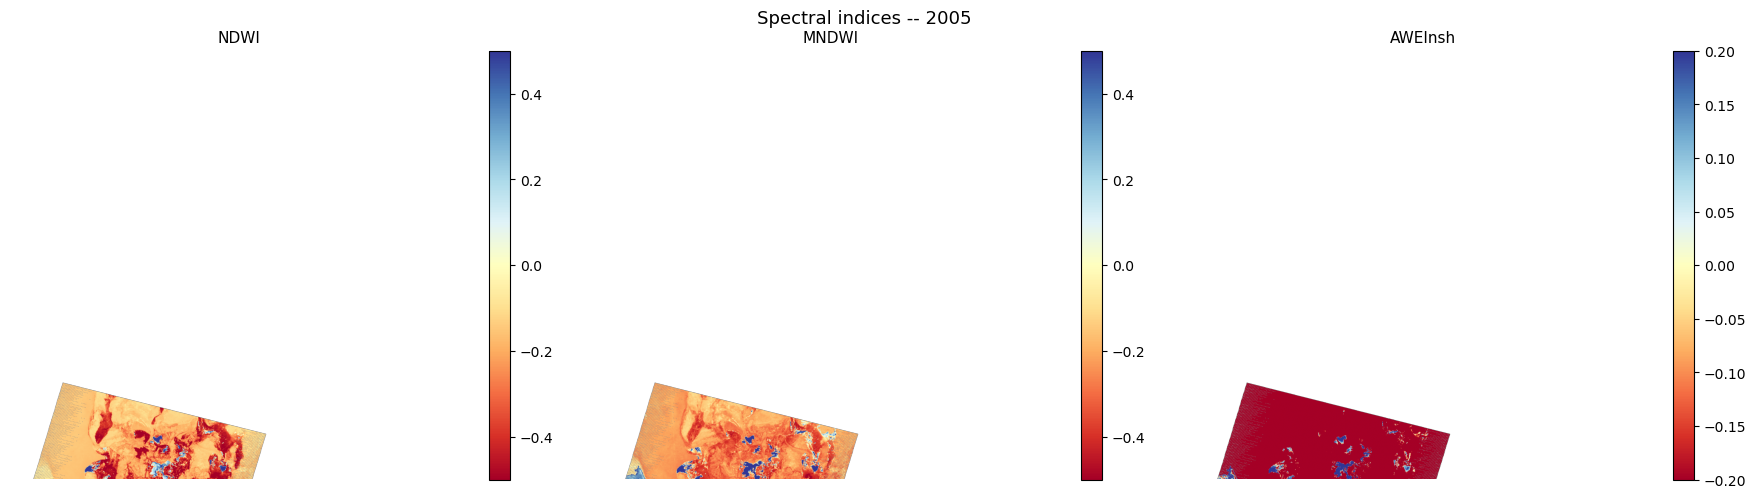

In [9]:
sample_year = min(all_indices.keys())
ndwi, mndwi, awei = all_indices[sample_year]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Spectral indices -- {sample_year}", fontsize=13)

for ax, arr, title, lo, hi in [
    (axes[0], ndwi,  "NDWI",   -0.5, 0.5),
    (axes[1], mndwi, "MNDWI",  -0.5, 0.5),
    (axes[2], awei,  "AWEInsh", -0.2, 0.2),
]:
    im = ax.imshow(arr, cmap="RdYlBu", vmin=lo, vmax=hi)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## 7. Binary water / non-water classification

Majority-vote rule: a pixel is **water (1)** when at least 2 of the 3 indices
exceed their threshold (all set to 0). This is more robust than any single index.


In [10]:
NDWI_T = MNDWI_T = AWEI_T = 0.0


def classify_water(ndwi, mndwi, awei):
    """Majority-vote water mask. Returns uint8: 1=water, 0=land, 255=nodata."""
    votes = (
        (ndwi  > NDWI_T ).astype(np.uint8) +
        (mndwi > MNDWI_T).astype(np.uint8) +
        (awei  > AWEI_T ).astype(np.uint8)
    )
    mask = (votes >= 2).astype(np.uint8)
    mask[np.isnan(ndwi) | np.isnan(mndwi) | np.isnan(awei)] = 255
    return mask


pixel_area_km2 = (RESOLUTION / 1000) ** 2
water_masks    = {}
water_area_km2 = {}

for year, (ndwi, mndwi, awei) in sorted(all_indices.items()):
    mask = classify_water(ndwi, mndwi, awei)
    water_masks[year]    = mask
    water_area_km2[year] = int(np.sum(mask == 1)) * pixel_area_km2
    sensor = "LS" if year < 2016 else "S2"
    print(f"{year} [{sensor}]  water: {water_area_km2[year]:7,.0f} km2")


2005 [LS]  water:     487 km2
2006 [LS]  water:       3 km2
2007 [LS]  water:       0 km2
2008 [LS]  water:      30 km2
2009 [LS]  water:       0 km2
2010 [LS]  water:       0 km2
2011 [LS]  water:       0 km2
2012 [LS]  water:       0 km2
2013 [LS]  water:       0 km2
2014 [LS]  water:      64 km2
2015 [LS]  water:      23 km2
2016 [S2]  water:     733 km2
2017 [S2]  water:       0 km2
2018 [S2]  water:       0 km2
2019 [S2]  water:       0 km2
2020 [S2]  water:      29 km2
2021 [S2]  water:       0 km2
2022 [S2]  water:       0 km2
2023 [S2]  water:       0 km2
2024 [S2]  water:       0 km2


## 8. Water extent maps -- all years


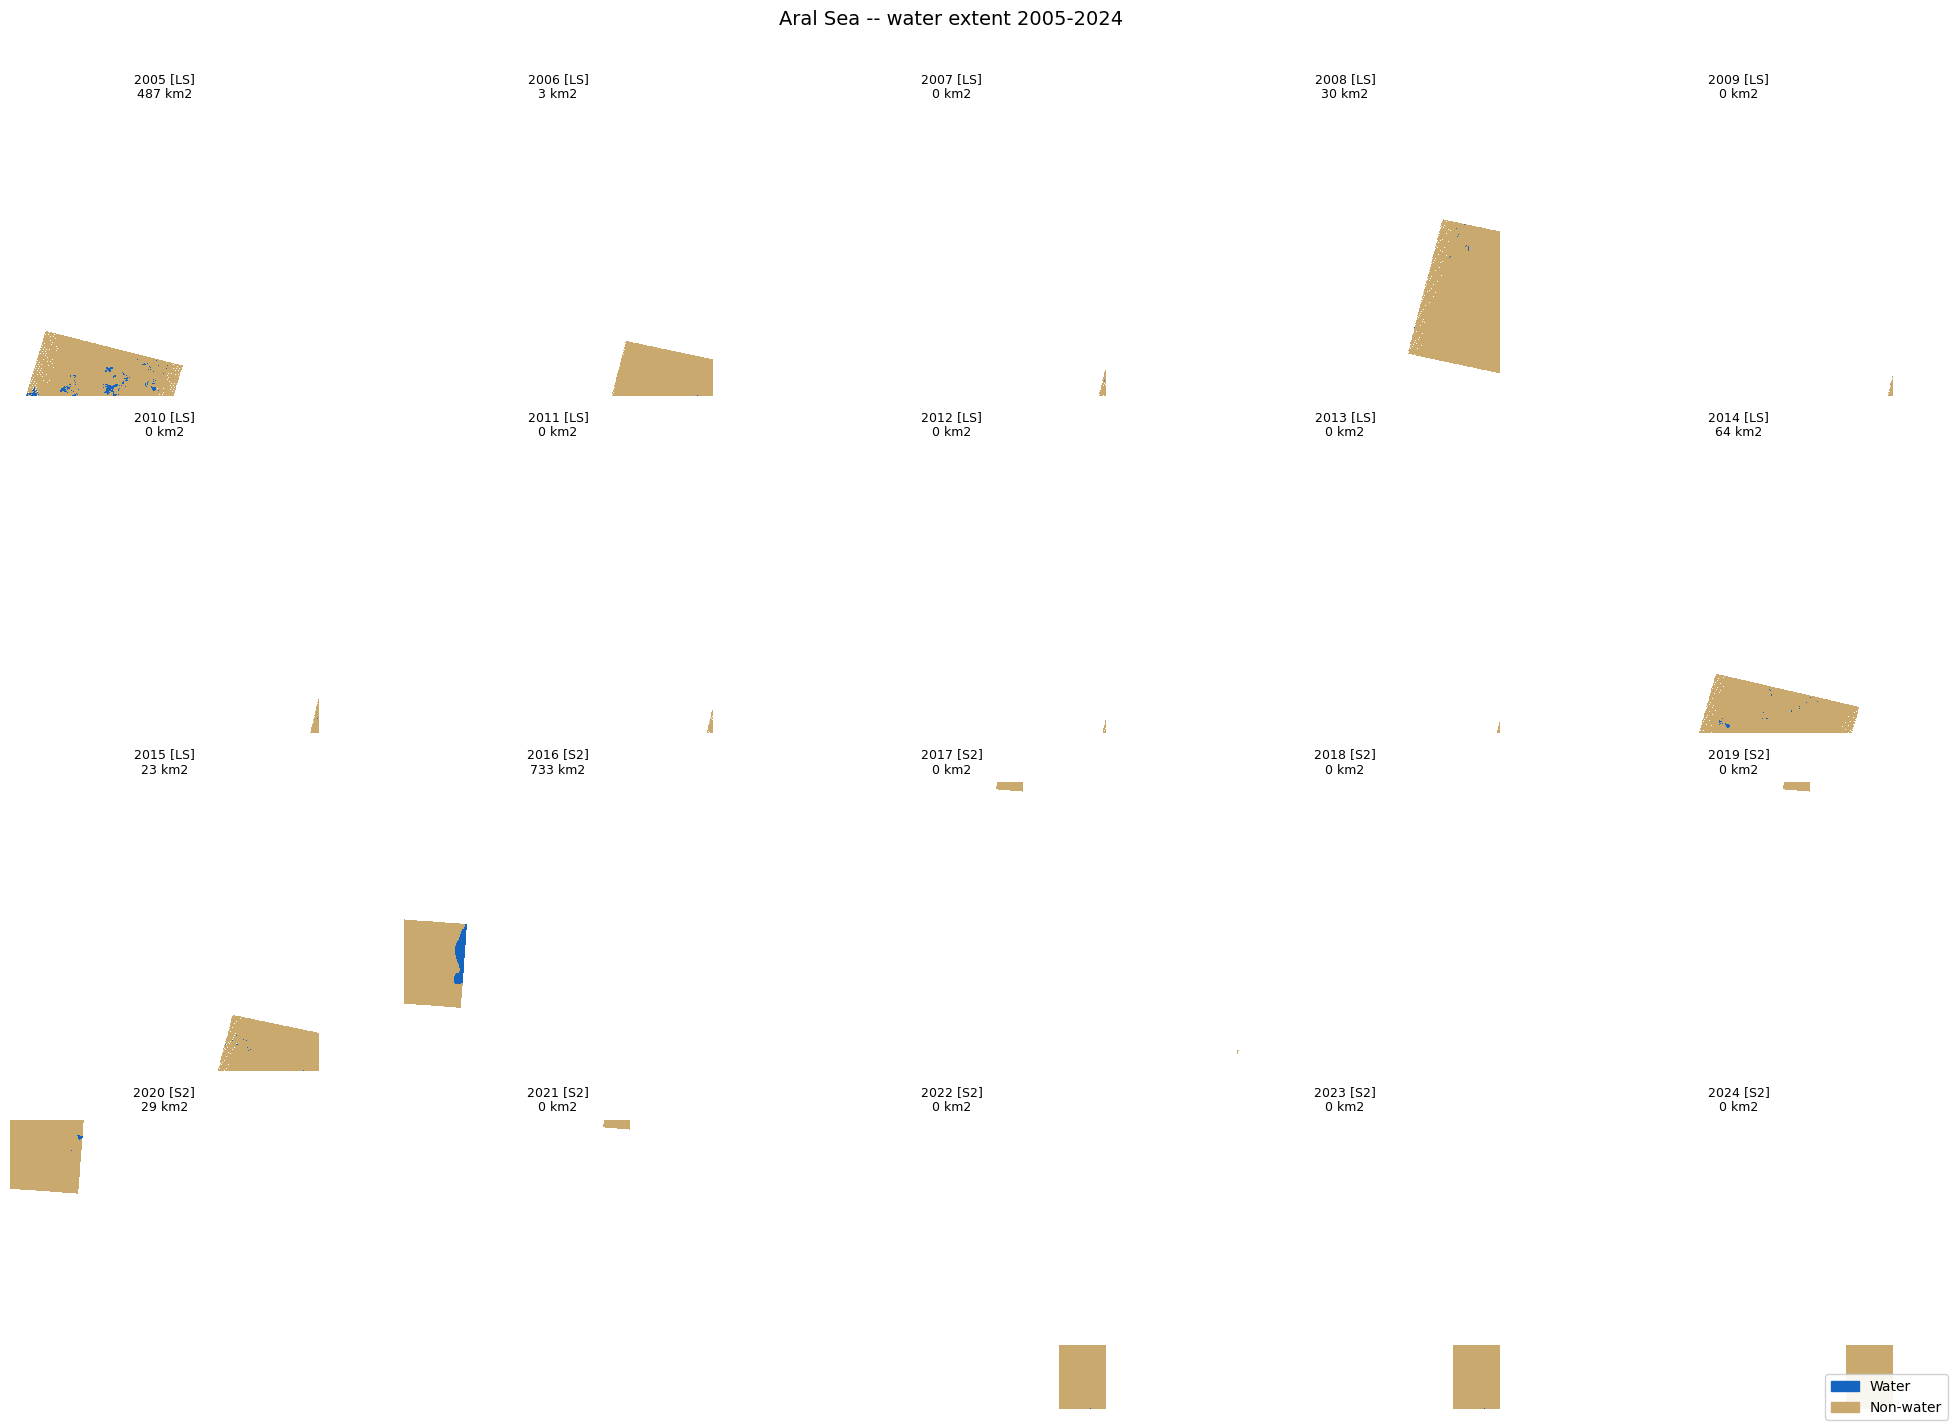

In [11]:
years  = sorted(water_masks.keys())
ncols  = 5
nrows  = (len(years) + ncols - 1) // ncols
cmap_w = mcolors.ListedColormap(["#c9a96e", "#1565c0"])

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for ax, year in zip(axes, years):
    disp = water_masks[year].copy().astype(float)
    disp[disp == 255] = np.nan
    ax.imshow(disp, cmap=cmap_w, vmin=0, vmax=1, interpolation="none")
    sensor = "LS" if year < 2016 else "S2"
    ax.set_title(f"{year} [{sensor}]\n{water_area_km2[year]:,.0f} km2", fontsize=9)
    ax.axis("off")

for ax in axes[len(years):]:
    ax.set_visible(False)

fig.legend(
    handles=[
        mpatches.Patch(color="#1565c0", label="Water"),
        mpatches.Patch(color="#c9a96e", label="Non-water"),
    ],
    loc="lower right", fontsize=10, framealpha=0.9,
)
fig.suptitle("Aral Sea -- water extent 2005-2024", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 9. Water area time series


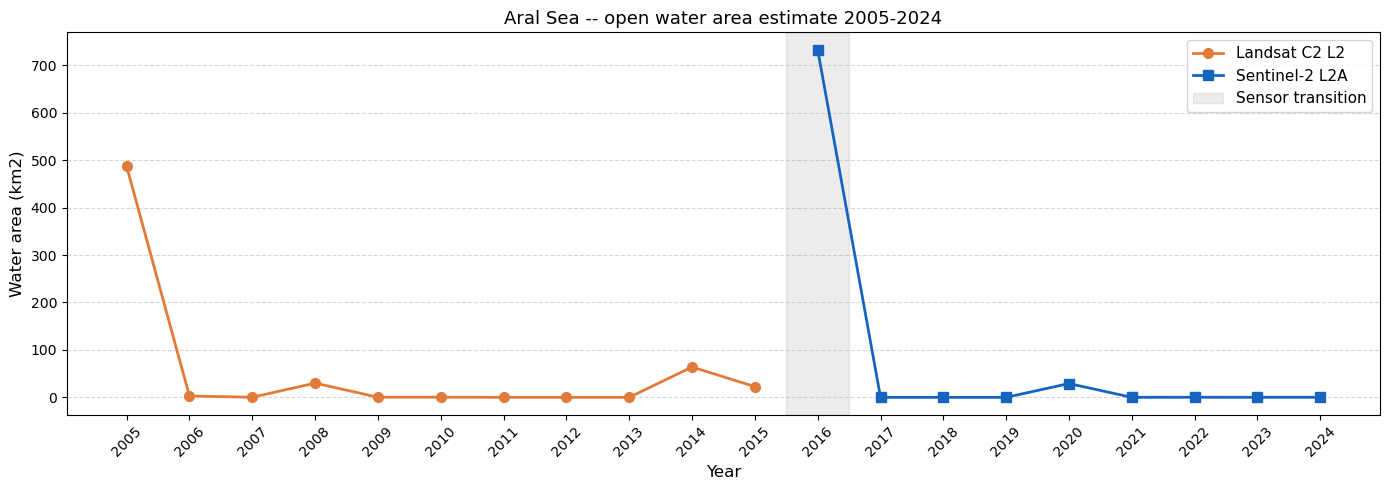

2005: 487 km2
2024:  0 km2
Change: -487 km2  (-100.0%)


In [12]:
ls_yrs = [y for y in years if y < 2016]
s2_yrs = [y for y in years if y >= 2016]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ls_yrs, [water_area_km2[y] for y in ls_yrs],
        "o-", color="#e07b39", lw=2, ms=7, label="Landsat C2 L2")
ax.plot(s2_yrs, [water_area_km2[y] for y in s2_yrs],
        "s-", color="#1565c0", lw=2, ms=7, label="Sentinel-2 L2A")
ax.axvspan(2015.5, 2016.5, color="grey", alpha=0.15, label="Sensor transition")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Water area (km2)", fontsize=12)
ax.set_title("Aral Sea -- open water area estimate 2005-2024", fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis="y", ls="--", alpha=0.5)
ax.set_xticks(years)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

first, last = years[0], years[-1]
delta = water_area_km2[last] - water_area_km2[first]
print(f"{first}: {water_area_km2[first]:,.0f} km2")
print(f"{last}:  {water_area_km2[last]:,.0f} km2")
print(f"Change: {delta:+,.0f} km2  ({delta / max(water_area_km2[first], 1) * 100:+.1f}%)")


## 10. Export timelapse GIF

Each frame = one year. Output: `aral_sea_timelapse.gif`


In [13]:
frames   = []
cmap_gif = mcolors.ListedColormap(["#c9a96e", "#1565c0"])

for year in sorted(water_masks.keys()):
    disp = water_masks[year].copy().astype(float)
    disp[disp == 255] = np.nan

    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)
    ax.imshow(disp, cmap=cmap_gif, vmin=0, vmax=1, interpolation="bilinear")
    sensor = "Landsat" if year < 2016 else "Sentinel-2"
    ax.set_title(
        f"Aral Sea  |  {year}  [{sensor}]\nWater area: {water_area_km2[year]:,.0f} km2",
        fontsize=12, pad=8,
    )
    ax.axis("off")
    ax.legend(
        handles=[
            mpatches.Patch(color="#1565c0", label="Water"),
            mpatches.Patch(color="#c9a96e", label="Non-water"),
        ],
        loc="lower right", fontsize=9, framealpha=0.9,
    )

    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    frames.append(iio.imread(buf))

out = "aral_sea_timelapse.gif"
iio.imwrite(out, frames, loop=0, duration=700)
print(f"Saved {len(frames)}-frame GIF -> {os.path.abspath(out)}")


Saved 20-frame GIF -> /Users/michallupa/eolabs/lab_1/aral_sea_timelapse.gif
